# Part 1 - Introduction to Catalyst

This notebook provides a basic introduction on how to use the [Catalyst.jl](https://github.com/SciML/Catalyst.jl) package's `@reaction_network` DSL to simulate chemical reaction network models.


## Part 1.1 - Basic DSL simulation workflow

Catalyst implements a so-called *domain-specific language* for *chemical reaction network* modelling. This is a specific type of model commonly used in biology and chemistry. Catalyst permits implementing this using an intuitive notation

Here we declare a simple birth-death process where a single species is produced and degraded at constant rates. 
- The model is stored in the variable.
- The model is enclosed by the `@reaction_network ... begin` notation.
- Each line is one "reaction event". First we write the reaction rate, followed by the reaction itself.
- We also need to import the Catalyst package with `using Catalyst`.

In [2]:
using Catalyst
bd_model = @reaction_network begin
    p, 0 --> X
    d, X --> 0
end

Model ##ReactionSystem#294:
Unknowns (1): see unknowns(##ReactionSystem#294)
  X(t)
Parameters (2): see parameters(##ReactionSystem#294)
  p
  d

To simulate the model we will first couple the model, an initial condition, parameter values, and a simulation time end point into a so-called `ODEProblem`. We can then simualte the model using `solve` (which requires the [OrdinaryDiffEq.jl](https://github.com/SciML/OrdinaryDiffEq.jl) package).

In [ ]:
using OrdinaryDiffEq
u0 = [:X => 2.0] 
tspan = (0.0, 10.0)
ps = [:p => 2.0, :d => 0.2]
ode_prob = ODEProblem(bd_model, u0, tspan, ps)
ode_sol = solve(ode_prob); # Here, `;` is used to suppress output printing in the notebook.

We can now plot the simulation using the `plot` command from the [Plots.jl](https://github.com/JuliaPlots/Plots.jl) package.

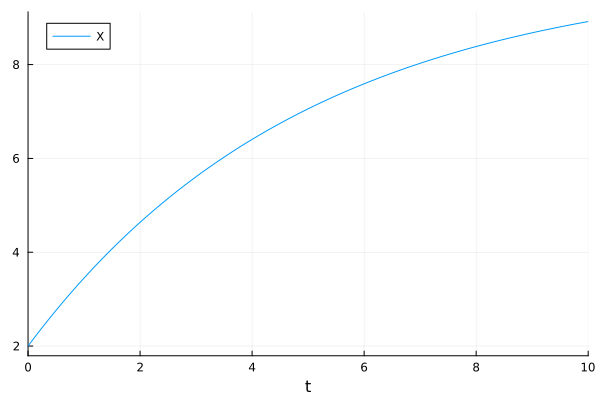

In [8]:
using Plots
plot(ode_sol)

## Part 1.2 - Available simulation types

Above we used an ODE simulation. Here, ODEs are generated from a chemical reaction network model using the "Reaction Rate Equations". To see the ODEs that we simulate we can use the `ode_model` function:

In [9]:
ode_model(bd_model)

Model ##ReactionSystem#294:
Equations (1):
  1 standard: see equations(##ReactionSystem#294)
Unknowns (1): see unknowns(##ReactionSystem#294)
  X(t)
Parameters (2): see parameters(##ReactionSystem#294)
  p
  d

Alternatively, Catalyst can simulate the model as a stochastic differential equation (generated through the *chemical Langevin equations) or as a jump process (generated through *stochastic chemical kinetics*, although the Gillespie algorithm with which this is simulated is often the most well-known term).

To make a SDE simulation, we simple use the [StochasticDiffEq.jl](https://github.com/SciML/StochasticDiffEq.jl) package and create an `SDEProblem` instead. Otherwise, the syntax is identical.

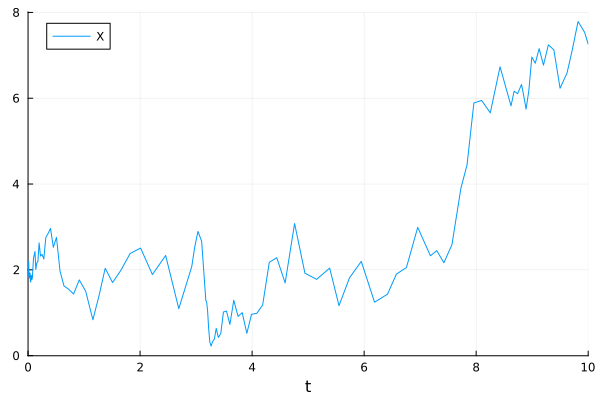

In [10]:
using StochasticDiffEq
sde_prob = SDEProblem(bd_model, u0, tspan, ps)
sde_sol = solve(sde_prob)
plot(sde_sol)

For jump simulations, we use the [JumpProcesses.jl](https://github.com/SciML/JumpProcesses.jl) package and go through a `JumpProblem`. 

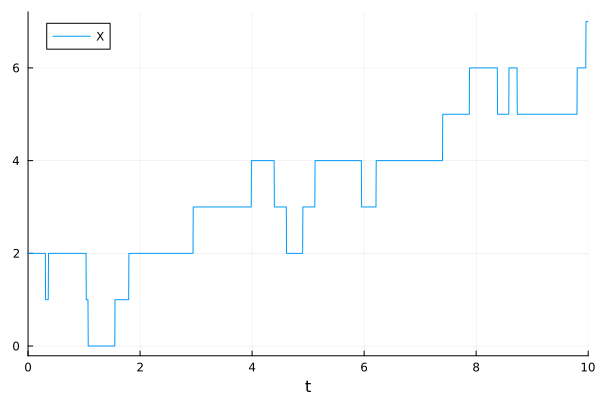

In [11]:
using JumpProcesses
jump_prob = JumpProblem(bd_model, u0, tspan, ps)
jump_sol = solve(jump_prob)
plot(jump_sol)

## Part 1.3 - Options for creating reactions in the DSL 

Next we will consider different approaches for creating reactions in the DSL.

#### Various reactions types

Sometimes, some species are produced (or degraded). This can be represented through the empty set (using either `0` or `∅`). Here we create a simple production/degradation network:

In [ ]:
rn_2 = @reaction_network begin
    p, 0 --> X    # X is produced.
    d, X --> 0    # X is degraded.
end

Model ##ReactionSystem#306:
Unknowns (1): see unknowns(##ReactionSystem#306)
  X(t)
Parameters (2): see parameters(##ReactionSystem#306)
  p
  d

A reaction's substrates and/or products can contain multiple species. These are separated by a `+`. Here we create a simple binding/unbinding network (where `X` and `Y` reversibly bind to form `XY`).

In [ ]:
rn_3 = @reaction_network begin
    kB, X + Y --> XY     # X and Y binds to form XY.
    kD, XY --> X + Y     # XY dissociates into X and Y.
end

Model ##ReactionSystem#315:
Unknowns (3): see unknowns(##ReactionSystem#315)
  X(t)
  Y(t)
  XY(t)
Parameters (2): see parameters(##ReactionSystem#315)
  kB
  kD

If multiple copies of a species participate in a reaction, the species can be preceded by a number indicating their stoichiometry. Here, we model a (reversible) dimerisation reaction (where 2 `X` molecules form a single molecule `X2`).

In [14]:
rn_4 = @reaction_network begin
    kB, 2X --> X2     # X dimerises to form X2.
    kD, X2 --> 2X     # X2 dissociates into 2 copies of X.
end

Model ##ReactionSystem#324:
Unknowns (2): see unknowns(##ReactionSystem#324)
  X(t)
  X2(t)
Parameters (2): see parameters(##ReactionSystem#324)
  kB
  kD

These features can be combined freely, and stoichiometries can even be nested.

In [15]:
wacky_reaction = @reaction_network begin
    kW, 2X + 3(Y +2Z) --> 5V + W    
end

Model ##ReactionSystem#333:
Unknowns (5): see unknowns(##ReactionSystem#333)
  X(t)
  Y(t)
  Z(t)
  V(t)
  ⋮
Parameters (1): see parameters(##ReactionSystem#333)
  kW

#### Bundling of similar reactions
Often, reaction networks contain reactions with similar structures. These can be bundled to create a more concise notation.

Reversible reactions can be modelled using a `<-->`. Here, the rate becomes a *tuple*, `(.,.)`, describing the *forward rate* followed by the *backward rate*. Here we create a production/degradation system in a single like:

In [16]:
rn_5 = @reaction_network begin
    (p,d), 0 <--> X     
end

Model ##ReactionSystem#342:
Unknowns (1): see unknowns(##ReactionSystem#342)
  X(t)
Parameters (2): see parameters(##ReactionSystem#342)
  p
  d

This is identical to the notation we used previously (to create `rn_2`):

In [17]:
rn_5 = @reaction_network begin
    p, 0 --> X    # X is produced.
    d, X --> 0    # X is degraded.
end

Model ##ReactionSystem#351:
Unknowns (1): see unknowns(##ReactionSystem#351)
  X(t)
Parameters (2): see parameters(##ReactionSystem#351)
  p
  d

Tuples can also be applied to the substrate/product expressions to bundle similar terms. If we have a system of two species `X` and `Y` degrading at rates `dX` and `dY`, these reactions can be bundled accordingly:

In [18]:
rn_6 = @reaction_network begin
    (dX,dY), (X,Y) --> 0
end

Model ##ReactionSystem#360:
Unknowns (2): see unknowns(##ReactionSystem#360)
  X(t)
  Y(t)
Parameters (2): see parameters(##ReactionSystem#360)
  dX
  dY

If we wish both reactions to use the same rate `d`, this is possible:

In [19]:
rn_7 = @reaction_network begin
    d, (X,Y) --> 0
end

Model ##ReactionSystem#369:
Unknowns (2): see unknowns(##ReactionSystem#369)
  X(t)
  Y(t)
Parameters (1): see parameters(##ReactionSystem#369)
  d

If we wish, bundling can be used for both substrates and products. Here, we create two reactions one where `X1` is converted into `X2` (at rate `kX`) and one where `Y1` is converted into `Y2` (at rate `kY`).

In [20]:
rn_8 = @reaction_network begin
    (kX,kY), (X1,Y1) --> (X2,Y2)
end

Model ##ReactionSystem#378:
Unknowns (4): see unknowns(##ReactionSystem#378)
  X1(t)
  X2(t)
  Y1(t)
  Y2(t)
Parameters (2): see parameters(##ReactionSystem#378)
  kX
  kY

Again, bundling can be combined in various ways, using any number of terms, and also be combined with reversible reactions:

In [21]:
wacky_network = @reaction_network begin
    ((pX, pY, pZ),d), (0, Y0, Z0) <--> (X, Y, Z1+Z2)
end

Model ##ReactionSystem#387:
Unknowns (6): see unknowns(##ReactionSystem#387)
  X(t)
  Y0(t)
  Y(t)
  Z0(t)
  ⋮
Parameters (4): see parameters(##ReactionSystem#387)
  pX
  pY
  pZ
  d

The important rule is that the rate is first split into the forward and backward reactions, and bundling is then applied (in this case, bundling has probably been applied overzealously, making it harder to figure out what is going on).

#### Using special symbols
Julia supports all Unicode characters, and these can be used in reaction networks.

The empty set can be represented through the `∅` symbol, and most arrows (e.g. `→`, `↣`, `↔`, `⇄`, etc.) can be used. E.g here we recreate our production/degradation reaction using a fancier notation.

In [22]:
rn_9 = @reaction_network begin
    (p,d), ∅ ↔ X 
end

Model ##ReactionSystem#396:
Unknowns (1): see unknowns(##ReactionSystem#396)
  X(t)
Parameters (2): see parameters(##ReactionSystem#396)
  p
  d

Such characters can also be used for species and parameters. E.g. when I worked on the bacterial sigma factor V (*σᵛ*), I could create a reaction where it is produced at the basic rate *v₀* using:



In [23]:
rn_10 = @reaction_network begin
    v₀, ∅ → σᵛ
end

Model ##ReactionSystem#405:
Unknowns (1): see unknowns(##ReactionSystem#405)
  σᵛ(t)
Parameters (1): see parameters(##ReactionSystem#405)
  v₀

If you want, backwards arrows can also be used:

In [24]:
rn_11 = @reaction_network begin
    d, 0 <-- X    # Equivalent to X --> 0
end

Model ##ReactionSystem#414:
Unknowns (1): see unknowns(##ReactionSystem#414)
  X(t)
Parameters (1): see parameters(##ReactionSystem#414)
  d

Also possible:

In [25]:
rn_12 = @reaction_network begin
    🍦, 😢 --> 😃
end

Model ##ReactionSystem#423:
Unknowns (2): see unknowns(##ReactionSystem#423)
  😢(t)
  😃(t)
Parameters (1): see parameters(##ReactionSystem#423)
  🍦

#### Non-constant reaction rates
So far we have assumed that reaction rates are all constant parameters, however, most expressions are permitted in the rate terms.

Let's assume that the activation of species `X` (converting it from an inactive form `X_i` to an active form `X_a`) is catalysed by the enzyme `E`. We can here put `E` in the reaction rate. In this case, we will also add model production/degradation of `E`.

In [26]:
rn_13 = @reaction_network begin
    (p,d), 0 <--> E
    E, X_i --> X_a
end

Model ##ReactionSystem#432:
Unknowns (3): see unknowns(##ReactionSystem#432)
  E(t)
  X_i(t)
  X_a(t)
Parameters (2): see parameters(##ReactionSystem#432)
  p
  d

When can now check the rate of change in `X_a` in the corresponding ODE using `ode_model`:

In [27]:
ode_model(rn_13)

Model ##ReactionSystem#432:
Equations (3):
  3 standard: see equations(##ReactionSystem#432)
Unknowns (3): see unknowns(##ReactionSystem#432)
  E(t)
  X_i(t)
  X_a(t)
Parameters (2): see parameters(##ReactionSystem#432)
  p
  d

If we want to also make the rate of the reaction `X_i --> X_a` scale with a parameter `k`, we can add that to the rate:

In [28]:
rn_14 = @reaction_network begin
    (p,d), 0 <--> E
    k*E, X_i --> X_a
end

Model ##ReactionSystem#441:
Unknowns (3): see unknowns(##ReactionSystem#441)
  E(t)
  X_i(t)
  X_a(t)
Parameters (3): see parameters(##ReactionSystem#441)
  p
  d
  k

In this case, an equivalent model can be achieved by adding `E` as a substrate and product to the reaction it catalyses:

In [29]:
rn_14 = @reaction_network begin
    (p,d), 0 <--> E
    k, X_i + E --> X_a + E
end

Model ##ReactionSystem#450:
Unknowns (3): see unknowns(##ReactionSystem#450)
  E(t)
  X_i(t)
  X_a(t)
Parameters (3): see parameters(##ReactionSystem#450)
  p
  d
  k

(in fact, if one carries out jump simulations this as advantageous, as their speed can be increased if all reaction rates are constant)

The Michaelis-Menten (*mm(X,v,K) = v\*X/(X + K)*) and Hill (*hill(X,v,K,n) = v\*X^n/(X^n + K^n)*) functions are frequently used in systems biology. These are natively supported. Here we create a model where the rate of production of `X` is determined by a Hill function according to the concentration of a transcription factor (`T`, again we let `T` be produced and degraded at a constant rate).

In [30]:
rn_15 = @reaction_network begin
    (p,d), 0 <--> T
    hill(T,v,K,n), 0 --> X
end

Model ##ReactionSystem#459:
Unknowns (2): see unknowns(##ReactionSystem#459)
  T(t)
  X(t)
Parameters (5): see parameters(##ReactionSystem#459)
  p
  d
  v
  K
  ⋮

A few other functions, such as repressive Michaelis-Menten and Hill functions are supported. It is also possible for the user to define their own functions and use them within the DSL.

In [31]:
my_function(k1,k2,E) = (k1+E)/(k2+E)
rn_16 = @reaction_network begin
    (p,d), 0 <--> E
    my_function(K1,K2,E), X_i --> X_a  # The name of the inputs to custom functions does not need to be the same as used to declare it.
end

Model ##ReactionSystem#468:
Unknowns (3): see unknowns(##ReactionSystem#468)
  E(t)
  X_i(t)
  X_a(t)
Parameters (4): see parameters(##ReactionSystem#468)
  p
  d
  K1
  K2

Generally, any valid expression can be used, and we can also use any normal Julia functions:

In [32]:
rn_17 = @reaction_network begin
    (p,d), 0 <--> E
    log(E) + k1^(1+k2), X_i --> X_a  
end

Model ##ReactionSystem#477:
Unknowns (3): see unknowns(##ReactionSystem#477)
  E(t)
  X_i(t)
  X_a(t)
Parameters (4): see parameters(##ReactionSystem#477)
  p
  d
  k1
  k2

The symbol `t` is reserved for time, and can be used to create time-dependent reactions. Here, `X` is produced at a cyclic rate (possibly modelling a circadian rythm):

In [33]:
rn_18 = @reaction_network begin
   A*(1 + sin(2π/T*t+ϕ))/2, 0 --> X
end

Model ##ReactionSystem#486:
Unknowns (1): see unknowns(##ReactionSystem#486)
  X(t)
Parameters (3): see parameters(##ReactionSystem#486)
  A
  T
  ϕ

Finally, reaction rates can also be constants. Here `X` is produced at the constant rate `1`.

In [34]:
rn_19 = @reaction_network begin
    1, 0 --> X
 end

Model ##ReactionSystem#495:
Unknowns (1): see unknowns(##ReactionSystem#495)
  X(t)

## Part 1.4 - Working with solutions
Next, we will consider some options for working with simulations. Let us first simulate a Brusselator ODE model.

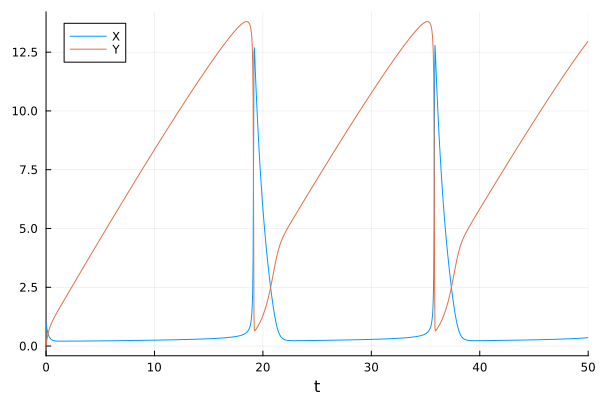

In [36]:
# Declare model.
brusselator = @reaction_network begin
    A, ∅ → X
    1, 2X + Y → 3X
    B, X → Y
    1, X → ∅
end

# Simulate the model for a specific condition.
u0 = [:X => 1.0, :Y => 0.0]
tspan = (0.0, 50.0)
ps = [:A => 1.0, :B => 4.0]
oprob = ODEProblem(brusselator, u0, tspan, ps)
sol = solve(oprob)
plot(sol)

If we only want to plot a specific species, we can use the `idxs` option to `plot`. Here we plot `X` only:

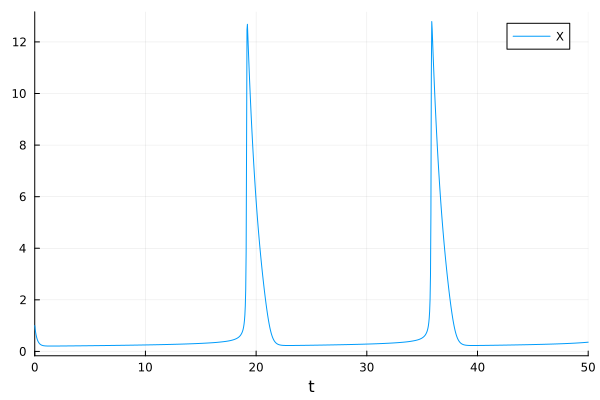

In [39]:
plot(sol; idxs = :X)

Phase-space plots can also be achieved through the `idxs` argument.

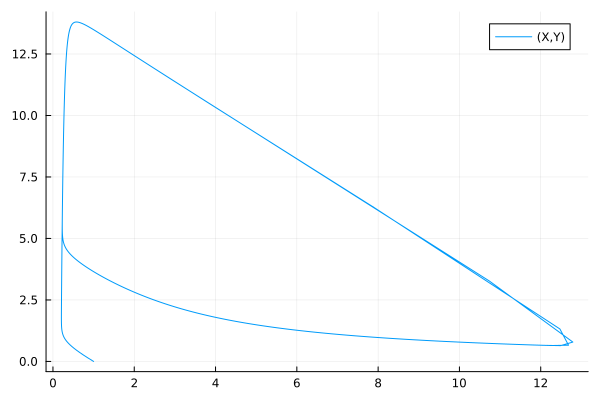

In [43]:
plot(sol; idxs = (:X, :Y))

Specifically, options such `linewidth`, `color`, `xguide`, etc. can be used to customise the plot.

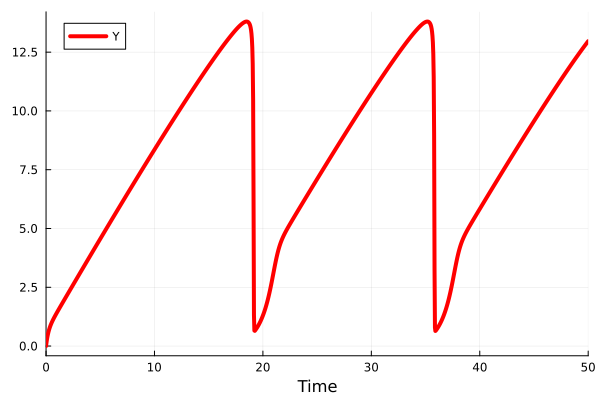

In [44]:
plot(sol; idxs = :Y, linewidth = 4, color = :red, xguide = "Time")

To access the values in a simulation we can index it with a specific variable, i.e. to get all `X` values we use

In [45]:
sol[:X]

131-element Vector{Float64}:
 1.0
 0.999001685234067
 0.9734864480362109
 0.8844251527616143
 0.7508006357683461
 0.6146887414277813
 0.48894112289706904
 0.3869343672849329
 0.31239947275594904
 0.263446749917359
 ⋮
 0.2385763133611301
 0.24375278745737863
 0.24999242168827523
 0.2575718583447165
 0.2668841686968
 0.27871367316885537
 0.2946008851554779
 0.3184961991703159
 0.3582865120591531

We can also sample it at specific time points using `()` brackets. Next, the solution will be automatically interpolated at the desiganted time points. We then use `idxs` to designate the species we are interested in.

In [46]:
sol(1:2:50; idxs = :X)

t: 1:2:49
u: 25-element Vector{Float64}:
 0.21192637700703565
 0.2127887884958501
 0.22140435336903597
 0.23156244775160414
 0.24389655099283325
 0.25939805860036114
 0.2802009481936376
 0.3115964200924792
 0.37476946462424465
 1.5374920601158915
 ⋮
 0.3462162476314619
 0.5226623980646847
 4.103519441410839
 0.23835796002568066
 0.2353274462452021
 0.24852517228501333
 0.2654637252609295
 0.2888430362865328
 0.32635856879722375

## Part 1.5 - Simulation options
The `solve` command takes various arguments to e.g. specify solver adaptivity, time step sizing, and similar. It also allows you to specify a solver algorithm. When an argument is not given, a default inputs will be found.

To e.g. specify that we wish to simulate the Brusselator using the stiff `Rodas5P` solver, we use:

In [49]:
solve(oprob, Rodas5P());

To read more about various solvers and options, refer to https://docs.sciml.ai/DiffEqDocs/stable/ (generally, https://docs.sciml.ai/Catalyst/stable/ contains extensive documentation on all features we will show, and also provide links to pages with additional documentation).

Especially when for jump simulations of larger models, the choice of algorithm is essential. Here we have performed benchmarks of various solvers, across various packages, for 5 different models (ranging from 9 to around 4,000 species). Let us consider the oscillating BCR model, when using the standard `Direct`method (corresponding Gillespie's direct method) , we cannot even complete the simulation. However, Catalyst automatically generates the dependency graphs required to run the more performant `RSSACR` algorithm (which is implemented by JumpProcesses.jl). 

# ![title](benchmarks.png)

(a-e) The (real) time to ODE-simulate the model until it reaches its steady state (comparison for various CRN modelling packages). 

(f-g) The (real) time to jump-simulate the model until the same time points (comparison for various CRN modelling packages). 

In fact, I am able to load up the 3,000 state BCR model and run for 500 time units on my laptop. We use the ReactionNetworkImporter package to load the model (as a .net file, SBML is also supported).

In [ ]:
using ReactionNetworkImporters, JumpProcesses
BCR = loadrxnetwork(BNGNetwork(), "BCR.net");

┌ Warning: /home/loman/.julia/packages/DataStructures/IrAJn/src/sorted_container_iteration.jl no longer exists, deleted all methods
└ @ Revise /home/loman/.julia/packages/Revise/b0dDX/src/packagedef.jl:748
┌ Warning: /home/loman/.julia/packages/SymbolicUtils/N76BL/src/printing.jl no longer exists, deleted all methods
└ @ Revise /home/loman/.julia/packages/Revise/b0dDX/src/packagedef.jl:748
┌ Warning: /home/loman/.julia/packages/Graphs/rEutM/src/frozenvector.jl no longer exists, deleted all methods
└ @ Revise /home/loman/.julia/packages/Revise/b0dDX/src/packagedef.jl:748
┌ Warning: /home/loman/.julia/packages/SymbolicUtils/N76BL/src/symbolic_ops/pow.jl no longer exists, deleted all methods
└ @ Revise /home/loman/.julia/packages/Revise/b0dDX/src/packagedef.jl:748
┌ Warning: /home/loman/.julia/packages/Graphs/rEutM/src/planarity.jl no longer exists, deleted all methods
└ @ Revise /home/loman/.julia/packages/Revise/b0dDX/src/packagedef.jl:748
┌ Warning: /home/loman/.julia/packages/Symbolic

In [ ]:
jin = JumpInputs(complete(BCR.rn), BCR.u0, (0.0, 500.0), BCR.p)
j_prob = JumpProblem(jin, RSSACR(); save_positions = (false, false))
sol = solve(j_prob; saveat = 0.1);

In [ ]:
plot(sol, idxs = :Activated_Syk)

## Monte Carlo simulations
In certain situations, we want to carry out multiple simulations simultaneously. Examples include making repeat simulations of a stochastic model, or simulating a model with several different initial conditions or parameter values. We can do this by creating an `EnsembleProblem`, which can then be simulated using various forms of parallelisation.

Let us consider a simple bistable switch model, and consider how the stochastic system randomly switches from an inactive state (where we set the initial condition) to an active state. First, we create a normal `SDEProblem`.

In [ ]:
using StochasticDiffEq
bistable_switch = @reaction_network begin
    v0 + hill(X,v,K,n), ∅ --> X
    deg, X --> ∅
end
u0 = [:X => 0.0]
tspan = (0.0, 1000.0)
p = [:v0 => 0.1, :v => 2.5, :K => 75.0, :n => 2.0, :deg => 0.01]
sprob = SDEProblem(bistable_switch, u0, tspan, p);

Next, we supply our `SDEProblem` to an `EnsembleProblem`. Here, since we wish to simulate the same SDE repeatedly, it is the only input to the `EnsembleProblem`. However, if we e.g. would like to use different initial conditions for every simulation, this kind of information is also supplied here.

In [ ]:
eprob = EnsembleProblem(sprob);

Finally, we can perform Monte Carlo simulations with the `solve` command, using the `trajectories` argument to designate how many simulations we want. We can plot the output using the `plot` command.

In [ ]:
esol = solve(eprob, ImplicitEM(); trajectories = 100)
plot(esol)

Sometimes, when plotting multiple Monte Carlo trajectories, the `linealpha` argument (which makes trajectories more transparent) can be useful.

In [ ]:
plot(esol; linealpha = 0.4)

When simulating an `EnsembleProblem`, an ensemble algorithm can be chosen (e.g. `EnsembleSerial()`, `EnsembleThreads()`, or `EnsembleGPUArray()`) to determine parallelisation strategy. By default `EnsembleThreads()` is used (best for problems where each individual simulation is quick).

Here, we use `EnsembleDistributed()` to parallelise over several processors.

In [ ]:
esol = solve(eprob, ImplicitEM(), EnsembleDistributed(); trajectories = 100)
plot(esol; linealpha = 0.5)